# Lab: 01_Regressione lineare usata per *classificazione* (1 variabile)

Obiettivo: mostrare **perché** usare una **regressione lineare** per un problema di **classificazione binaria** (0/1) è possibile ma **non ideale**.

Useremo:
- un solo input `x` (una variabile),
- `LinearRegression` di **scikit-learn** per stimare i parametri **w** (pendenza) e **b** (intercetta),
- una soglia (threshold) per trasformare l’output continuo in una classe 0/1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Per grafici in Jupyter
%matplotlib inline


## 1) Dataset di esempio (1 feature)

Immagina `x` come una misura semplice (es. dimensione carcinoma), e `y` come la classe:
- `y=0` = “no” ovvero esame negativo, quindi tumore benigno
- `y=1` = “sì” ovvero esame positivo, quindi tumore maligno

**Nota:** in un dataset reale, avresti molti più punti e spesso rumore.


In [2]:
x = np.array([0, 1, 1.5, 2, 3, 4, 5])
y = np.array([0, 0, 0, 0, 1, 1, 1])

# scikit-learn vuole X come matrice (n_righe, n_feature)
X = x.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7, 1)
y shape: (7,)


## 2) Visualizziamo i dati

Ogni punto è un esempio: sull’asse x la variabile, sull’asse y la classe (0 o 1).


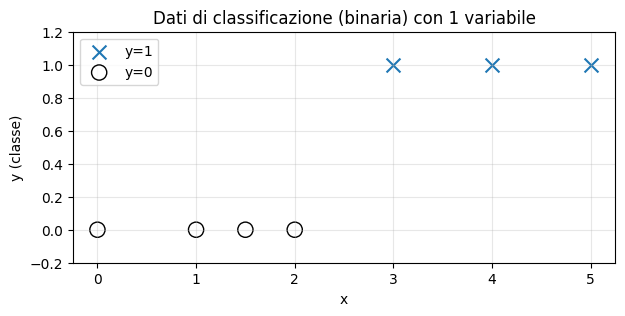

In [3]:
pos = y == 1
neg = y == 0

plt.figure(figsize=(7,3))
plt.scatter(x[pos], y[pos], marker="x", s=100, label="y=1")
plt.scatter(x[neg], y[neg], marker="o", s=120, facecolors="none", edgecolors="black", label="y=0")
plt.ylim(-0.2, 1.2)
plt.xlabel("x")
plt.ylabel("y (classe)")
plt.title("Dati di classificazione (binaria) con 1 variabile")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3) Fit con Regressione Lineare

La regressione lineare stima:


y_hat = w x + b


dove:
- **w** è la pendenza (coefficiente),
- **b** è l’intercetta.

Con scikit-learn otteniamo direttamente `coef_` e `intercept_`.


In [4]:
lin = LinearRegression()
lin.fit(X, y)

w = float(lin.coef_[0])
b = float(lin.intercept_)

print(f"w (pendenza)  = {w:.4f}")
print(f"b (intercetta)= {b:.4f}")


w (pendenza)  = 0.2685
b (intercetta)= -0.2043


## 4) Tracciamo la retta stimata

Ora confrontiamo la retta con i dati binari.


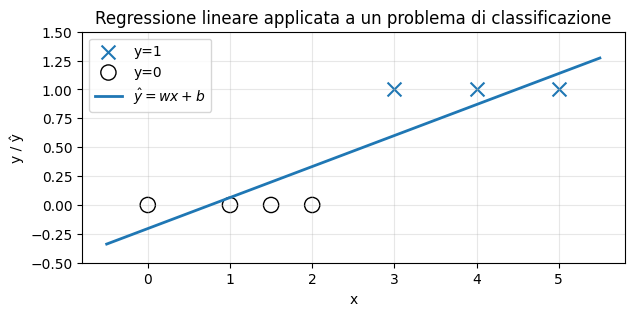

In [5]:
x_line = np.linspace(x.min()-0.5, x.max()+0.5, 200)
y_line = w*x_line + b

plt.figure(figsize=(7,3))
plt.scatter(x[pos], y[pos], marker="x", s=100, label="y=1")
plt.scatter(x[neg], y[neg], marker="o", s=120, facecolors="none", edgecolors="black", label="y=0")
plt.plot(x_line, y_line, linewidth=2, label=r"$\hat{y}=wx+b$")

plt.ylim(-0.5, 1.5)
plt.xlabel("x")
plt.ylabel("y / ŷ")
plt.title("Regressione lineare applicata a un problema di classificazione")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5) Da output continuo a classe (threshold)

La regressione lineare produce un valore **continuo** (es. 0.73, 1.12, -0.10).
Per trasformarlo in classe 0/1 usiamo una soglia, per esempio:

- se y_hat > 0.5 ⇒ predici **1**
- altrimenti ⇒ predici **0**

> Questa soglia è una scelta “pratica” e non viene ottimizzata dalla regressione lineare.


In [6]:
y_hat = lin.predict(X)                      # valori continui
y_pred = (y_hat >= 0.5).astype(int)         # classi 0/1 con soglia

df = pd.DataFrame({"x": x, "y_true": y, "y_hat": y_hat, "y_pred": y_pred})
df


,x,y_true,y_hat,y_pred
0,0.0,0,-0.204280,0
1,1.0,0,0.064202,0
2,1.5,0,0.198444,0
3,2.0,0,0.332685,0
4,3.0,1,0.601167,1
5,4.0,1,0.869650,1
6,5.0,1,1.138132,1


## 6) Valutazione (accuracy + confusion matrix)


In [7]:
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print(f"Accuracy: {acc:.3f}")
print("Confusion matrix:", cm)


Accuracy: 1.000
Confusion matrix: [[4 0]
 [0 3]]


## 7) Perché non è ideale (intuizione)

Con la regressione lineare:

- y_hat **non è** una probabilità (può essere <0 o >1).
- Minimizza l’errore quadratico medio (MSE), non una loss pensata per classificazione.
- La soglia è “aggiunta a mano” e può risultare instabile.

**Alternative standard per classificazione:**
- **Regressione logistica** (output tra 0 e 1, interpretabile come probabilità)
- Alberi / Random Forest / Gradient Boosting


## Esercizi veloci

1. Aggiungi al dataset iniziale almeno 2 x di valori maggiori di 20 e verifica come cambia la previsione mantenedo la stessa soglia
2. Cambia la soglia da 0.5 a 0.6 e osserva come cambiano `y_pred`, accuracy e confusion matrix.  
